<a href="https://colab.research.google.com/github/JZhou3083/cse234-w25-PA/blob/jz_assign/matmul_triton_wip.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import triton
import triton.language as tl
import time

In [ ]:
def is_cuda():
    return triton.runtime.driver.active.get_current_target().backend == "cuda"

In [ ]:
def is_hip_mi200():
    target = triton.runtime.driver.active.get_current_target()
    return target.backend == 'hip' and target.arch == 'gfx90a'

In [ ]:
def get_device():
  return triton.runtime.driver.active.get_active_torch_device()
DEVICE = get_device()

# Vector Addition

In [ ]:
@triton.jit
def add_kernel(x_ptr,  # *Pointer* to first input vector.
               y_ptr,  # *Pointer* to second input vector.
               output_ptr,  # *Pointer* to output vector.
               n_elements,  # Size of the vector.
               BLOCK_SIZE: tl.constexpr,  # Number of elements each program should process.
               # NOTE: `constexpr` so it can be used as a shape value.
               ):
    # There are multiple 'programs' processing different data. We identify which program
    # we are here:
    pid = tl.program_id(axis=0)  # We use a 1D launch grid so axis is 0.
    # This program will process inputs that are offset from the initial data.
    # For instance, if you had a vector of length 256 and block_size of 64, the programs
    # would each access the elements [0:64, 64:128, 128:192, 192:256].
    # Note that offsets is a list of pointers:
    block_start = pid * BLOCK_SIZE
    offsets = block_start + tl.arange(0, BLOCK_SIZE)
    # Create a mask to guard memory operations against out-of-bounds accesses.
    mask = offsets < n_elements
    # Load x and y from DRAM, masking out any extra elements in case the input is not a
    # multiple of the block size.
    x = tl.load(x_ptr + offsets, mask=mask)
    y = tl.load(y_ptr + offsets, mask=mask)
    output = x + y
    # Write x + y back to DRAM.
    tl.store(output_ptr + offsets, output, mask=mask)

In [ ]:
def add(x: torch.Tensor, y: torch.Tensor):
    # We need to preallocate the output.
    output = torch.empty_like(x)
    assert x.device == DEVICE and y.device == DEVICE and output.device == DEVICE
    n_elements = output.numel()
    # The SPMD launch grid denotes the number of kernel instances that run in parallel.
    # It is analogous to CUDA launch grids. It can be either Tuple[int], or Callable(metaparameters) -> Tuple[int].
    # In this case, we use a 1D grid where the size is the number of blocks:
    grid = lambda meta: (triton.cdiv(n_elements, meta['BLOCK_SIZE']), )
    # NOTE:
    #  - Each torch.tensor object is implicitly converted into a pointer to its first element.
    #  - `triton.jit`'ed functions can be indexed with a launch grid to obtain a callable GPU kernel.
    #  - Don't forget to pass meta-parameters as keywords arguments.
    add_kernel[grid](x, y, output, n_elements, BLOCK_SIZE=1024)
    # We return a handle to z but, since `torch.cuda.synchronize()` hasn't been called, the kernel is still
    # running asynchronously at this point.
    return output

In [ ]:
torch.manual_seed(0)
size = 98432
x = torch.rand(size, device=DEVICE)
y = torch.rand(size, device=DEVICE)
output_torch = x + y
output_triton = add(x, y)
print(output_torch)
print(output_triton)
print(f'The maximum difference between torch and triton is '
      f'{torch.max(torch.abs(output_torch - output_triton))}')

tensor([1.3713, 1.3076, 0.4940,  ..., 0.4024, 1.7918, 1.0686], device='cuda:0')
tensor([1.3713, 1.3076, 0.4940,  ..., 0.4024, 1.7918, 1.0686], device='cuda:0')
The maximum difference between torch and triton is 0.0


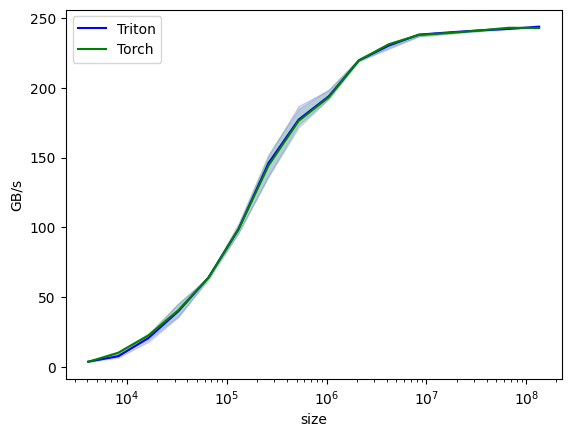

vector-add-performance:
           size      Triton       Torch
0        4096.0    3.820895    3.692308
1        8192.0    7.680000   10.172185
2       16384.0   20.686868   22.588235
3       32768.0   39.896105   40.688742
4       65536.0   63.999998   63.999998
5      131072.0   98.698793   98.500999
6      262144.0  146.068350  144.352422
7      524288.0  177.124332  176.172043
8     1048576.0  193.797922  193.131640
9     2097152.0  219.428568  219.428568
10    4194304.0  230.152770  231.099613
11    8388608.0  237.988205  237.736394
12   16777216.0  239.583247  239.218859
13   33554432.0  241.019639  240.941181
14   67108864.0  242.128075  242.922734
15  134217728.0  243.713192  242.743484


In [ ]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['size'],  # Argument names to use as an x-axis for the plot.
        x_vals=[2**i for i in range(12, 28, 1)],  # Different possible values for `x_name`.
        x_log=True,  # x axis is logarithmic.
        line_arg='provider',  # Argument name whose value corresponds to a different line in the plot.
        line_vals=['triton', 'torch'],  # Possible values for `line_arg`.
        line_names=['Triton', 'Torch'],  # Label name for the lines.
        styles=[('blue', '-'), ('green', '-')],  # Line styles.
        ylabel='GB/s',  # Label name for the y-axis.
        plot_name='vector-add-performance',  # Name for the plot. Used also as a file name for saving the plot.
        args={},  # Values for function arguments not in `x_names` and `y_name`.
    ))
def benchmark(size, provider):
    x = torch.rand(size, device=DEVICE, dtype=torch.float16)
    y = torch.rand(size, device=DEVICE, dtype=torch.float16)
    quantiles = [0.5, 0.2, 0.8]
    if provider == 'torch':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: x + y, quantiles=quantiles)
    if provider == 'triton':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: add(x, y), quantiles=quantiles)
    gbps = lambda ms: 3 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
    return gbps(ms), gbps(max_ms), gbps(min_ms)

benchmark.run(print_data=True, show_plots=True)

# 2D matrix adding kernel

In [ ]:
@triton.jit
def add_kernel_2d(x_ptr,
                  y_ptr,
                  output_ptr,
                  M,
                  N,
                  BLOCK_SIZE_M: tl.constexpr,
                  BLOCK_SIZE_N: tl.constexpr,):
  pid_m = tl.program_id(0)
  pid_n = tl.program_id(1)

  offsets_m = pid_m*BLOCK_SIZE_M +tl.arange(0, BLOCK_SIZE_M)
  offsets_n = pid_n*BLOCK_SIZE_N+tl.arange(0, BLOCK_SIZE_N)

  mask_m = offsets_m<M
  mask_n = offsets_n<N
  mask = mask_m[:, None] & mask_n[None, :]


  # Compute flat indices for 2D access
  x = tl.load(x_ptr + offsets_m[:, None] * N + offsets_n[None, :], mask=mask)
  y = tl.load(y_ptr + offsets_m[:, None] * N + offsets_n[None, :], mask=mask)

  output = x + y

  tl.store(output_ptr + offsets_m[:, None] * N + offsets_n[None, :], output, mask=mask)


In [ ]:
def add_2d(x: torch.Tensor, y: torch.Tensor):
    output = torch.empty_like(x)
    M, N = x.shape
    grid = lambda meta: (triton.cdiv(M, meta['BLOCK_SIZE_M']),
                         triton.cdiv(N, meta['BLOCK_SIZE_N']))
    add_kernel_2d[grid](x, y, output, M, N, BLOCK_SIZE_M=32, BLOCK_SIZE_N=32)
    return output

In [ ]:
# Test result
torch.manual_seed(0)
M, N = 256, 384
x = torch.rand((M, N), device=DEVICE)
y = torch.rand((M, N), device=DEVICE)
output_torch = x + y
output_triton = add_2d(x, y)

print("Output from PyTorch:")
print(output_torch)
print("Output from Triton:")
print(output_triton)
print(f'The maximum difference between torch and triton is '
      f'{torch.max(torch.abs(output_torch - output_triton))}')


Output from PyTorch:
tensor([[1.3713, 1.3076, 0.4940,  ..., 0.3855, 1.4943, 1.4478],
        [0.5162, 1.0012, 0.6585,  ..., 0.4783, 0.9484, 1.9693],
        [0.1601, 1.1110, 0.9578,  ..., 0.9419, 1.1034, 0.5426],
        ...,
        [0.9669, 1.0692, 0.8695,  ..., 0.2962, 0.7198, 1.1833],
        [0.5777, 1.1041, 1.9073,  ..., 1.3520, 1.3086, 1.1136],
        [0.3310, 0.8356, 0.7641,  ..., 0.9641, 0.9512, 0.6445]],
       device='cuda:0')
Output from Triton:
tensor([[1.3713, 1.3076, 0.4940,  ..., 0.3855, 1.4943, 1.4478],
        [0.5162, 1.0012, 0.6585,  ..., 0.4783, 0.9484, 1.9693],
        [0.1601, 1.1110, 0.9578,  ..., 0.9419, 1.1034, 0.5426],
        ...,
        [0.9669, 1.0692, 0.8695,  ..., 0.2962, 0.7198, 1.1833],
        [0.5777, 1.1041, 1.9073,  ..., 1.3520, 1.3086, 1.1136],
        [0.3310, 0.8356, 0.7641,  ..., 0.9641, 0.9512, 0.6445]],
       device='cuda:0')
The maximum difference between torch and triton is 0.0


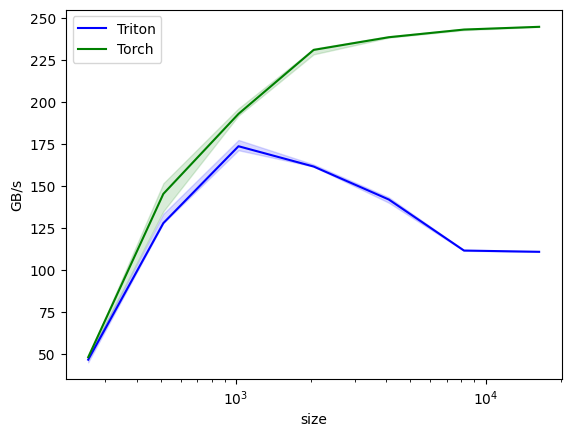

matrix-add-performance:
      size      Triton       Torch
0    256.0   46.722434   48.188237
1    512.0  127.999995  145.420113
2   1024.0  173.758727  193.036827
3   2048.0  161.684218  231.099613
4   4096.0  142.051393  238.638138
5   8192.0  111.676374  243.213851
6  16384.0  110.927655  244.841842


In [ ]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['size'],
        x_vals=[2**i for i in range(8, 15)],  # Matrix sizes: 256x256 to 16384x16384
        x_log=True,
        line_arg='provider',
        line_vals=['triton', 'torch'],
        line_names=['Triton', 'Torch'],
        styles=[('blue', '-'), ('green', '-')],
        ylabel='GB/s',
        plot_name='matrix-add-performance',
        args={},
    ))
def benchmark(size, provider):
    x = torch.rand((size, size), device=DEVICE, dtype=torch.float16)
    y = torch.rand((size, size), device=DEVICE, dtype=torch.float16)
    quantiles = [0.5, 0.2, 0.8]
    if provider == 'torch':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: x + y, quantiles=quantiles)
    if provider == 'triton':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: add_2d(x, y), quantiles=quantiles)
    gbps = lambda ms: 3 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
    return gbps(ms), gbps(max_ms), gbps(min_ms)

benchmark.run(print_data=True, show_plots=True)


# Fused Softmax

In [ ]:
def naive_softmax(x):
    """Compute row-wise softmax of X using native pytorch

    We subtract the maximum element in order to avoid overflows. Softmax is invariant to
    this shift.
    """
    # read  MN elements ; write M  elements
    x_max = x.max(dim=1)[0]
    # read MN + M elements ; write MN elements
    z = x - x_max[:, None]
    # read  MN elements ; write MN elements
    numerator = torch.exp(z)
    # read  MN elements ; write M  elements
    denominator = numerator.sum(dim=1)
    # read MN + M elements ; write MN elements
    ret = numerator / denominator[:, None]
    # in total: read 5MN + 2M elements ; wrote 3MN + 2M elements
    return ret

@triton.jit
def softmax_kernel(output_ptr, input_ptr, input_row_stride, output_row_stride,
                   n_rows, n_cols, BLOCK_SIZE:tl.constexpr,
                   num_stages:tl.constexpr):
    # starting row of the program
    row_start = tl.program_id(0)
    row_step = tl.num_prorgams(0)
    for row_idx in range(row_start, n_rows, row_step, num_stages= num_stages):
        # The stride represents how much we need to increase the pointer to advance 1 row
        row_start_ptr = input_ptr + row_idx * input_row_stride
        # The block size is the next power of two greater than n_cols, so we can fit each
        # row in a single block
        col_offsets =tl.arange(0, BLOCK_SIZE)
        input_ptrs = row_start_ptr + col_offsets
        # Load the row into SRAM, using a mask since BLOCK_SIZE may be > than n_cols
        mask = col_offsets < n_cols
        row = tl.load(input_ptrs, mask =mask, other = -float('inf'))
        # Substract maximum for numerical stability
        row_minus_max = row - tl.max(row,axis =0)

        numerator = tl.exp(row_minus_max)
        denominator = tl.sum(numerator, axis = 0)
        softmax_output = numerator/denominator

        # write output to DRAM
        output_row_start_ptr = output_ptr + row_idx * output_row_stride
        output_ptrs = out_row_start_ptr + col_offsets
        tl.store(output_ptrs, softmax_output, mask =mask )




In [ ]:
x = torch.tensor([[1,23,3],[33,2,6]])
x_max = x.max(dim=1)[0]
z  = x- x_max[:,None]
numerator = torch.exp(z)
denominator = numerator.sum(dim=1)
denominator
# ret = numerator/denominator[:,None]
# print(ret)

tensor([1., 1.])

In [ ]:
"""
PA2 Part 2: MatMul+Relu+Add Fused Optimization.
The kernel uses several optimization techniques:

  1. Shared memory tiling.
  2. Register tiling.
  3. Cooperative fetching.
  4. Operator Fusion
  5. Write cache / epilogue fusion.

Fill in the missing parts (marked with TODO).
"""

# -----------------------------------------------------------------------------
# Tiling parameters - You will need to change these to achieve better results.
# -----------------------------------------------------------------------------
BLOCK_M = 128  # Tile size in the M dimension.
BLOCK_N = 128 # Tile size in the N dimension.
BLOCK_K = 32 # Tile size in the K dimension.


# -----------------------------------------------------------------------------
# Triton Kernel: Matrix Multiplication + ReLU + Add
#
# The kernel uses:
#   Step 1: Tile assignment (each kernel computes a tile of C)
#   Step 2: Shared memory tiling + Cooperative Fetching: Load tiles of A and B.
#   Step 3: Register tiling: Use a register accumulator.
#   Step 4: Add and ReLU fusion
#   Step 5: Write cache/Epilogue: Write the final tile back to global memory.
# -----------------------------------------------------------------------------
@triton.jit
def matmul_add_relu_kernel_fp16(
    a_ptr, b_ptr, c_ptr, d_ptr,
    M: tl.constexpr, N: tl.constexpr, K: tl.constexpr,
    stride_am: tl.constexpr, stride_ak: tl.constexpr,
    stride_bk: tl.constexpr, stride_bn: tl.constexpr,
    stride_cm: tl.constexpr, stride_cn: tl.constexpr,
    stride_dm: tl.constexpr, stride_dn: tl.constexpr,
    BLOCK_M: tl.constexpr, BLOCK_N: tl.constexpr, BLOCK_K: tl.constexpr,
):
    # -------------------------------------------------------------------------
    # Step 1: Tile: Assignment
    #
    # Each kernel instance is mapped to a tile in the output matrix C.
    # Compute the starting indices (m_start, n_start) for this tile.
    # -------------------------------------------------------------------------
    # TODO: Compute the tile indices using program_id(0) for M and program_id(1) for N.
    ...

    # -------------------------------------------------------------------------
    # Step 2: Register Tiling
    # -------------------------------------------------------------------------
    # TODO: Initialize the accumulator "acc" with zeros (dtype: float16).
    acc = ...

    # -------------------------------------------------------------------------
    # Step 3: Shared Memory Tiling & Cooperative Fetching.
    # Compute pointers to the sub-tiles of A and B that are needed to compute
    # the current C tile. The offsets here serve to load BLOCK_SIZE_M x BLOCK_SIZE_K
    # and BLOCK_SIZE_K x BLOCK_SIZE_N blocks from A and B respectively.
    # -------------------------------------------------------------------------
    # TODO: Finish code below
    for k in range(0, ...):
        ...
    # -------------------------------------------------------------------------
    # Step 4: Apply ReLU and Add C to the accumulator
    # -------------------------------------------------------------------------
    # TODO: Finish code below
    ...

    # -------------------------------------------------------------------------
    # Step 5: Write Cache / Epilogue Fusion: Write the computed tile to D.
    # -------------------------------------------------------------------------
    # TODO: Finish code below
    ...

In [ ]:
def matmul_add_relu_fp16(a: torch.Tensor, b: torch.Tensor, c: torch.Tensor) -> torch.Tensor:
    """
    Computes Output = ReLU(A @ B + C) using fp16 precision for maximum throughput.
    """
    M, K = a.shape
    K2, N = b.shape
    assert K == K2, "Incompatible dimensions"

    d = torch.empty((M, N), device=a.device, dtype=torch.float16)
    # Create launch grid
    grid = (triton.cdiv(M, BLOCK_M), triton.cdiv(N, BLOCK_N))

    matmul_add_relu_kernel_fp16[grid](
        a, b, c, d,
        M, N, K,
        a.stride(0), a.stride(1),
        b.stride(0), b.stride(1),
        c.stride(0), c.stride(1),
        d.stride(0), d.stride(1),
        BLOCK_M=BLOCK_M, BLOCK_N=BLOCK_N, BLOCK_K=BLOCK_K
    )
    return d

In [ ]:
# Reference implementation using PyTorch
def reference_matmul_add_relu(A, B, C):
    result = torch.matmul(A, B).add(C).relu_()
    return result

In [ ]:
# -----------------------------------------------------------------------------
# Accuracy Tests
# -----------------------------------------------------------------------------
if __name__ == "__main__":
    torch.manual_seed(0)
    a = torch.randn((512, 512), device=torch.device("cuda"), dtype=torch.float16)
    b = torch.randn((512, 512), device=torch.device("cuda"), dtype=torch.float16)
    c = torch.randn((512, 512), device=torch.device("cuda"), dtype=torch.float16)
    triton_output = matmul_add_relu_fp16(a, b, c)
    torch_output = reference_matmul_add_relu(a, b, c)
    print(f"triton_output_with_fp16_inputs={triton_output}")
    print(f"torch_output_with_fp16_inputs={torch_output}")
    rtol = 1e-2 if is_hip_mi200() else 0.032
    if torch.allclose(triton_output, torch_output, atol=0.15, rtol=rtol):
        print("✅ Triton and Torch match")
    else:
        diff = triton_output - torch_output
        abs_diff = torch.abs(diff)
        max_abs_diff = torch.max(abs_diff)
        print(f"❌ Triton and Torch differ: {max_abs_diff=}")

In [ ]:
# -----------------------------------------------------------------------------
# Performance Benchmark
# IMPORTANT: DO NOT CHANGE THIS CODE.
# THIS IS THE EXACT CODE THAT WILL BE USED TO GRADE YOUR IMPLEMENTATION.
# ANY CHANGES TO THIS CODE (INCLUDING DIMENSIONS, REPEATS, etc.)
# WILL CAUSE YOU TO HAVE DIFFERENT SPEEDUP RESULTS.
# -----------------------------------------------------------------------------
M = 2048
K = 2048
N = 2048

# KEEP THESE MATRICES IN FP16. FP32 WILL NOT PROVIDE ACCURATE RESULTS
A = torch.randn((M, K), device="cuda", dtype=torch.float16)
B = torch.randn((K, N), device="cuda", dtype=torch.float16)
C = torch.randn((M, N), device="cuda", dtype=torch.float16)

# warmup
_ = matmul_add_relu_fp16(A, B, C)
_ = reference_matmul_add_relu(A, B, C)

REPEATS = 5000

# time your implementation
print("Triton implementation")
torch.cuda.synchronize()
start = time.perf_counter()
for _ in range(REPEATS):
    _ = matmul_add_relu_fp16(A, B, C)
torch.cuda.synchronize()
triton_time = (time.perf_counter() - start) / REPEATS

# time pytorch
print("PyTorch implementation")
torch.cuda.synchronize()
start = time.perf_counter()
for _ in range(REPEATS):
    _ = reference_matmul_add_relu(A, B, C)
torch.cuda.synchronize()
torch_time = (time.perf_counter() - start) / REPEATS

print(f"Performance comparison for matrix multiplication ({M}x{K} @ {K}x{N}):")
print(f"Triton implementation: {triton_time*1000:.2f} ms")
print(f"PyTorch implementation: {torch_time*1000:.2f} ms")

print(f"\nSpeedup of Triton vs PyTorch: {torch_time/triton_time:.2f}x")

In [ ]:
# Write your grid search here.